# Assignment: Pandas Groupby with Hurricane Data

In [52]:
# Import Numpy, Pandas and Matplotlib and set the display options.
# Use the following code to load a CSV file of the NOAA IBTrACS hurricane dataset:

In [53]:
import pandas as pd
url = 'https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r00/access/csv/ibtracs.ALL.list.v04r00.csv'
df = pd.read_csv(url, parse_dates=['ISO_TIME'], usecols=range(12),
                 skiprows=[1], na_values=[' ', 'NOT_NAMED'],
                 keep_default_na=False, dtype={'NAME': str})
df.tail()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WMO_WIND,WMO_PRES
716160,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 06:00:00,NR,23.0325,89.3509,NaN,NaN
716161,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 09:00:00,NR,23.3337,89.6178,NaN,NaN
716162,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 12:00:00,NR,23.6263,89.8799,NaN,NaN
716163,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 15:00:00,NR,23.9143,90.1400,NaN,NaN
716164,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 18:00:00,NR,24.2000,90.4000,NaN,NaN


In [54]:
# Basin Key: (NI - North Indian, SI - South Indian, WP - Western Pacific, SP - Southern Pacific, 
# EP - Eastern Pacific, NA - North Atlantic)
# How many rows does this dataset have?
# How many North Atlantic hurricanes are in this dataset?

In [55]:
print(len(df))

716165


In [56]:
# 716,165 rows

In [57]:
na_storms = df[df['BASIN'] == 'NA']
na_count = na_storms['SID'].nunique()
na_count

2344

In [58]:
# 2344 NA storms

### 1) Get the unique values of the BASIN, SUBBASIN, and NATURE columns

In [59]:
print("BASIN:", df['BASIN'].unique())
print("SUBBASIN:", df['SUBBASIN'].unique())
print("NATURE:", df['NATURE'].unique())

BASIN: ['NI' 'SI' 'NA' 'EP' 'WP' 'SP' 'SA']
SUBBASIN: ['BB' 'AS' 'MM' 'GM' 'NA' 'CS' 'WA' 'EA' 'CP']
NATURE: ['NR' 'TS' 'ET' 'SS' 'MX' 'DS']


### 2) Rename the WMO_WIND and WMO_PRES columns to WIND and PRES

In [60]:
df = df.rename(columns={'WMO_WIND': 'WIND', 'WMO_PRES': 'PRES'})
print(df.columns)

Index(['SID', 'SEASON', 'NUMBER', 'BASIN', 'SUBBASIN', 'NAME', 'ISO_TIME',
       'NATURE', 'LAT', 'LON', 'WIND', 'PRES'],
      dtype='object')


### 3) Get the 10 largest rows in the dataset by WIND

In [61]:
largest_winds = df.nlargest(10, 'WIND')
largest_winds

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WIND,PRES
666142,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 12:00:00,TS,17.3,-105.6,185.0,872.0
666140,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 06:00:00,TS,16.5,-105.4,180.0,886.0
666144,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 18:00:00,TS,18.3,-105.3,180.0,878.0
427655,1980214N11330,1980,57,NA,GM,ALLEN,1980-08-07 18:00:00,TS,21.8,-86.4,165.0,899.0
178210,1935241N23291,1935,46,NA,NA,NaN,1935-09-03 00:00:00,TS,24.6,-80.5,160.0,892.0
178211,1935241N23291,1935,46,NA,NA,NaN,1935-09-03 02:00:00,TS,24.8,-80.8,160.0,892.0
178213,1935241N23291,1935,46,NA,GM,NaN,1935-09-03 06:00:00,TS,25.1,-81.1,160.0,NaN
482093,1988253N12306,1988,74,NA,CS,GILBERT,1988-09-14 00:00:00,TS,19.7,-83.8,160.0,888.0
552477,1997253N12255,1997,81,EP,MM,LINDA,1997-09-12 06:00:00,TS,17.1,-109.6,160.0,902.0
605764,2005289N18282,2005,97,NA,CS,WILMA,2005-10-19 12:00:00,TS,17.3,-82.8,160.0,882.0


### 4) Group the data on SID and get the 10 largest hurricanes by WIND

In [62]:
hurricane_max_winds = df.groupby('SID')['WIND'].max()
largest_hurricanes = hurricane_max_winds.nlargest(10)
largest_hurricanes

SID
2015293N13266    185.0
1980214N11330    165.0
1935241N23291    160.0
1988253N12306    160.0
1997253N12255    160.0
2005289N18282    160.0
2019236N10314    160.0
1998295N12284    155.0
2005261N21290    155.0
2009288N07267    155.0
Name: WIND, dtype: float64

In [63]:
top_10_named = df.groupby(['SID', 'NAME'])['WIND'].max().nlargest(10)
print(top_10_named)

SID            NAME    
2015293N13266  PATRICIA    185.0
1980214N11330  ALLEN       165.0
1988253N12306  GILBERT     160.0
1997253N12255  LINDA       160.0
2005289N18282  WILMA       160.0
2019236N10314  DORIAN      160.0
1998295N12284  MITCH       155.0
2005261N21290  RITA        155.0
2009288N07267  RICK        155.0
2017242N16333  IRMA        155.0
Name: WIND, dtype: float64


### 5) Make a bar chart of the wind speed of the 20 strongest-wind hurricanes

In [64]:
# Use the name on the x-axis.

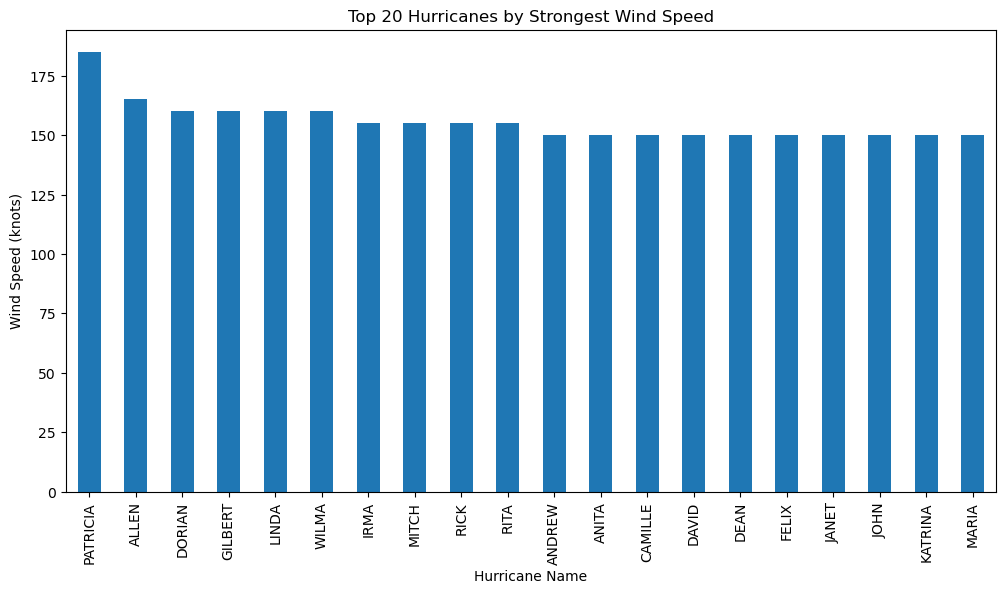

In [65]:
import matplotlib.pyplot as plt

df.groupby('NAME')['WIND'].max().nlargest(20).plot(kind='bar', figsize=(12,6), title="Top 20 Hurricanes by Strongest Wind Speed")

plt.xlabel('Hurricane Name')
plt.ylabel('Wind Speed (knots)')
plt.show()

### 6) Plot the count of all datapoints by Basin

In [66]:
# as a bar chart

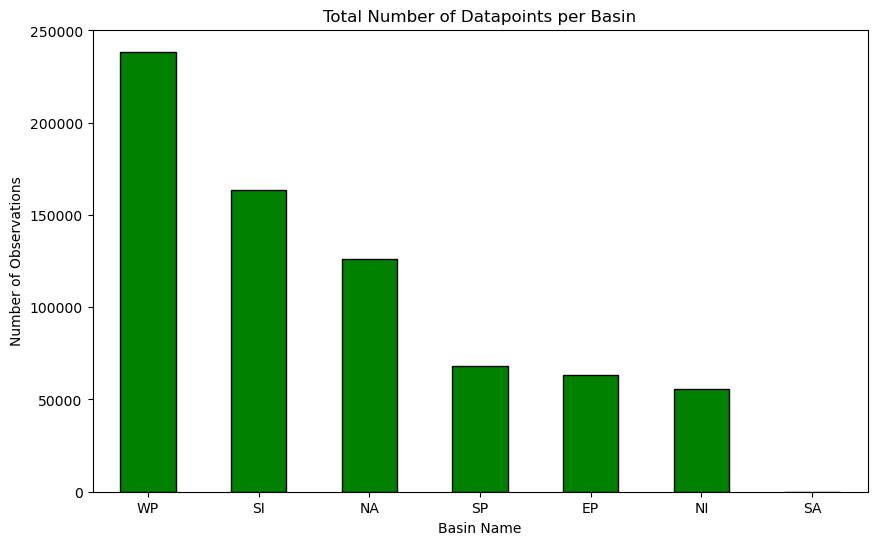

In [67]:
basin_counts = df.groupby('BASIN').size().sort_values(ascending=False)

basin_counts.plot(kind='bar', figsize=(10, 6), color='green', edgecolor='black')

plt.title('Total Number of Datapoints per Basin')
plt.xlabel('Basin Name')
plt.ylabel('Number of Observations')
plt.xticks(rotation=0)
plt.show()

### 7) Plot the count of unique hurricanes by Basin

In [68]:
# as a bar chart.

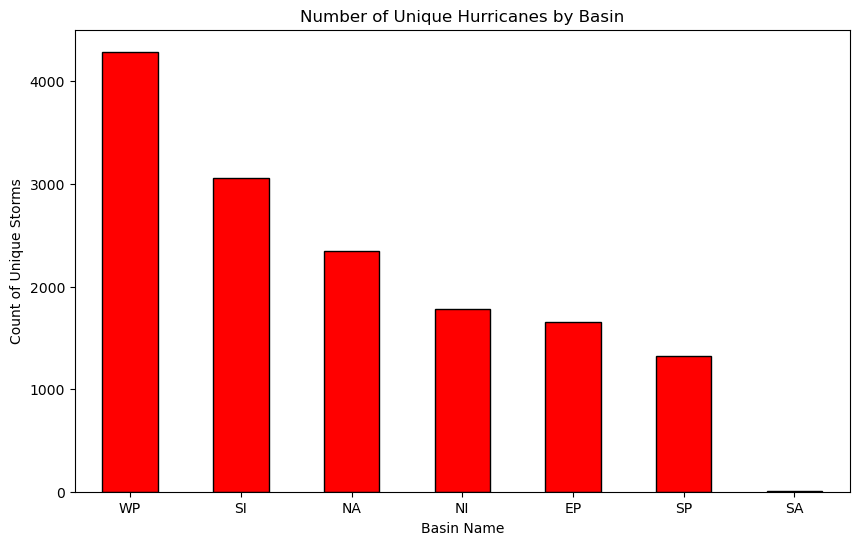

In [69]:
unique_hurricanes = df.groupby('BASIN')['SID'].nunique().sort_values(ascending=False)

unique_hurricanes.plot(kind='bar', figsize=(10, 6), color='red', edgecolor='black')

plt.title('Number of Unique Hurricanes by Basin')
plt.xlabel('Basin Name')
plt.ylabel('Count of Unique Storms')
plt.xticks(rotation=0)
plt.show()

### 8) Make a hexbin of the location of datapoints in Latitude and Longitude

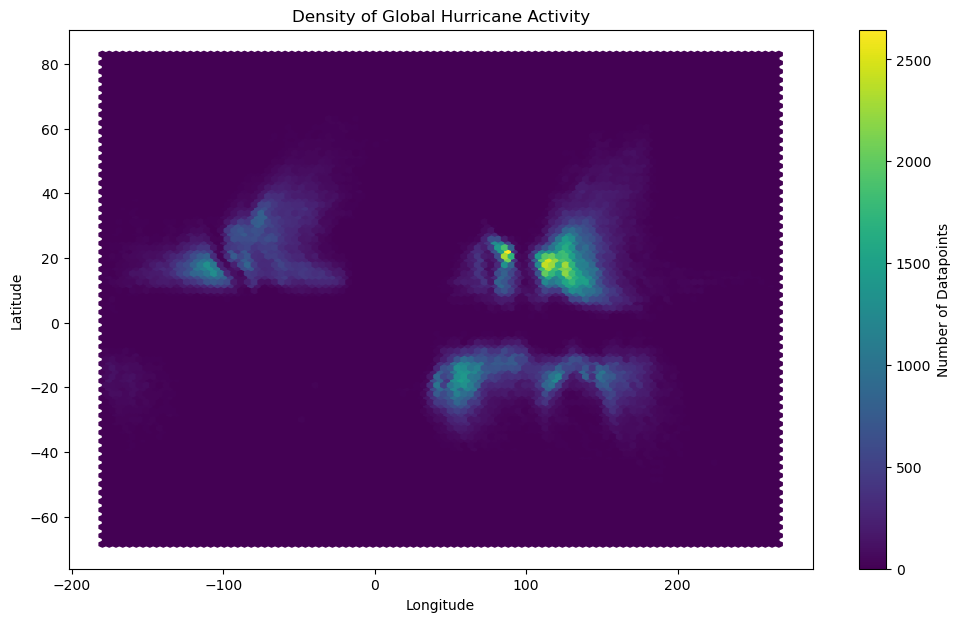

In [70]:
ax = df.plot.hexbin(x='LON', y='LAT', gridsize=100, cmap='viridis', figsize=(12, 7), colorbar=False)

plt.colorbar(ax.collections[0], label='Number of Datapoints')

plt.title('Density of Global Hurricane Activity')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

### 9) Find Hurricane Katrina (from 2005) and plot its track as a scatter plot

In [71]:
# First find the SID of this hurricane.
# Next get this hurricane’s group and plot its position as a scatter plot. 
# Use wind speed to color the points.

In [72]:
katrina = df[(df['NAME'] == 'KATRINA') & (df['SEASON'] == 2005)]['SID'].unique()[0]
katrina

'2005236N23285'

In [73]:
# katrina SID: 2005236N23285

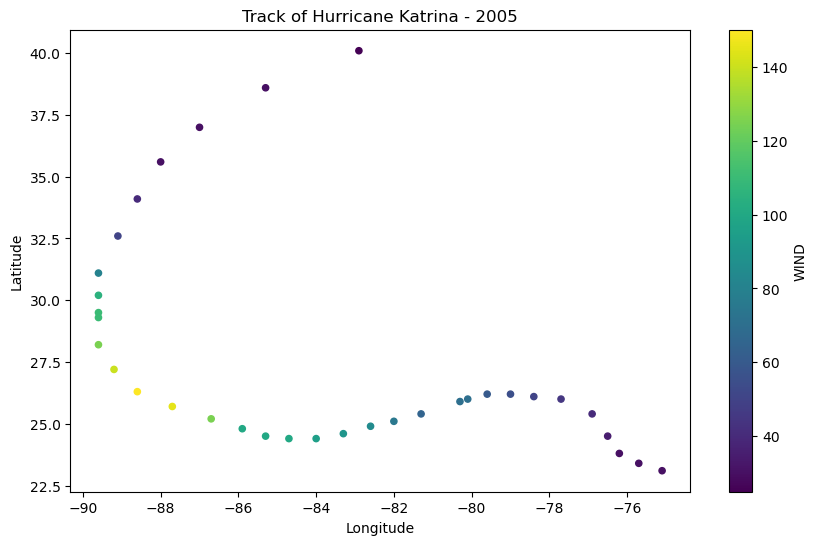

In [74]:
gb = df.groupby('SID')
katrina_data = gb.get_group(katrina)

katrina_data.plot.scatter(x='LON', y='LAT', c='WIND', cmap='viridis', 
                          figsize=(10, 6), sharex=False)

plt.title('Track of Hurricane Katrina - 2005')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

### 10) Make time the index on your dataframe

In [75]:
df['ISO_TIME'] = pd.to_datetime(df['ISO_TIME'])
df = df.set_index('ISO_TIME')

df = df.sort_index()
df.head()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,NATURE,LAT,LON,WIND,PRES
ISO_TIME,,,,,,,,,,,
1842-10-25 03:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.9000,80.3000,NaN,NaN
1842-10-25 06:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8709,79.8265,NaN,NaN
1842-10-25 09:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8431,79.3524,NaN,NaN
1842-10-25 12:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8188,78.8772,NaN,NaN
1842-10-25 15:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8000,78.4000,NaN,NaN


### 11) Plot the count of all datapoints per year as a timeseries

In [76]:
# You should use resample
# Which years stand out as having anomalous hurricane activity?

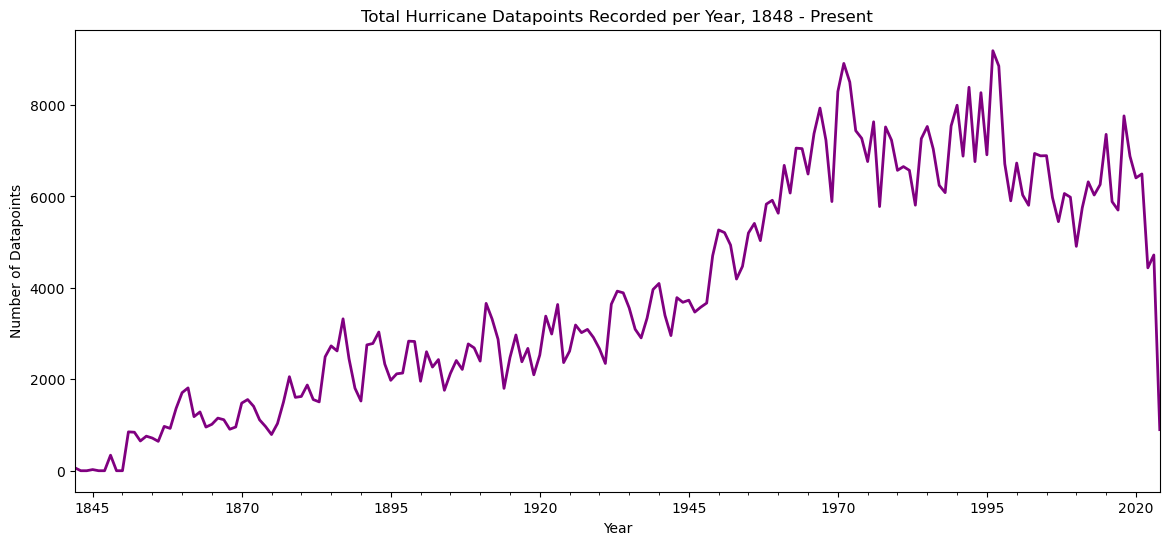

In [77]:
# Split-Apply-Combine: 
yearly_datapoints = df.resample('YE').size()

plt.figure(figsize=(14, 6))
yearly_datapoints.plot(color='purple', linewidth=2)

plt.title('Total Hurricane Datapoints Recorded per Year, 1848 - Present')
plt.ylabel('Number of Datapoints')
plt.xlabel('Year')

plt.show()

In [78]:
yearly_datapoints = df.resample('YE').size().nlargest(5)
yearly_datapoints

ISO_TIME
1996-12-31    9189
1971-12-31    8911
1997-12-31    8854
1972-12-31    8503
1992-12-31    8389
dtype: int64

In [79]:
# Which years stand out as having anomalous hurricane activity?
# The highest peaks of the line graph are 1996 and 1971, which are shown in the dataset above as being the years with the most
# most hurricane datapoints. 1997 and 1972 and 1992 were also anomalous in years with 